<a href="https://colab.research.google.com/github/msbarath/Data-Science---1-21-24CS030-/blob/main/DS_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ride-Hailing — When Is Surge Demand Highest?

## 1. Business Problem

This assignment focuses on analyzing ride-hailing data to understand demand patterns, identify high-demand locations and times, and explore factors influencing trip duration. The primary goal is to provide insights and actionable recommendations for optimizing driver positioning and potentially managing surge pricing based on demand concentrations.

## 2. Dataset Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/ride_hailing_surge_demand_dataset.csv')

# Display the first 5 rows of the dataframe
print("Dataset Head:")
display(df.head())

# Display basic information about the dataset
print("\nDataset Info:")
df.info()

# Display descriptive statistics
print("\nDataset Description:")
display(df.describe(include='all'))

Dataset Head:


,Trip_ID,Pickup_Area,Drop_Area,Trip_Time,Fare,Trip_Duration,Weather,Event_Status
0,TRIP000001,East Zone,Railway Station,2026-06-28 03:03:00,152.79,17.6,Clear,NaN
1,TRIP000002,Industrial Area,South Zone,2026-08-10 07:12:00,369.15,39.7,Cloudy,NaN
2,TRIP000003,Railway Station,IT Corridor,2026-07-05 17:52:00,320.75,36.4,Cloudy,NaN
3,TRIP000004,University,East Zone,2026-07-25 12:37:00,187.92,20.0,Clear,NaN
4,TRIP000005,IT Corridor,Airport,2026-07-12 22:40:00,343.89,40.5,Cloudy,Concert



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6008 entries, 0 to 6007
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Trip_ID        6008 non-null   object 
 1   Pickup_Area    6000 non-null   object 
 2   Drop_Area      6008 non-null   object 
 3   Trip_Time      6008 non-null   object 
 4   Fare           5999 non-null   float64
 5   Trip_Duration  5998 non-null   float64
 6   Weather        6000 non-null   object 
 7   Event_Status   479 non-null    object 
dtypes: float64(2), object(6)
memory usage: 375.6+ KB

Dataset Description:


,Trip_ID,Pickup_Area,Drop_Area,Trip_Time,Fare,Trip_Duration,Weather,Event_Status
count,6008,6000,6008,6008,5999.000000,5998.000000,6000,479
unique,6000,12,12,5852,NaN,NaN,4,3
top,TRIP005249,Central,South Zone,2026-06-27 10:55:00,NaN,NaN,Clear,Local Event
freq,2,537,526,3,NaN,NaN,3480,230
mean,NaN,NaN,NaN,NaN,282.676106,32.213321,NaN,NaN
std,NaN,NaN,NaN,NaN,82.477433,9.065638,NaN,NaN
min,NaN,NaN,NaN,NaN,62.030000,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,230.285000,25.800000,NaN,NaN
50%,NaN,NaN,NaN,NaN,277.400000,31.600000,NaN,NaN
75%,NaN,NaN,NaN,NaN,327.405000,38.000000,NaN,NaN


In [3]:
# 1. Handle Missing Values

# Impute categorical columns with mode
for col in ['Pickup_Area', 'Weather']:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Missing values in '{col}' imputed with mode: {mode_val}")

# Impute numerical columns with median
for col in ['Fare', 'Trip_Duration']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Missing values in '{col}' imputed with median: {median_val}")

# Fill NaN in 'Event_Status' with 'No Event'
if df['Event_Status'].isnull().any():
    df['Event_Status'] = df['Event_Status'].fillna('No Event')
    print("Missing values in 'Event_Status' filled with 'No Event'")

# 2. Convert Trip_Time to datetime
df['Trip_Time'] = pd.to_datetime(df['Trip_Time'])
print("\n'Trip_Time' column converted to datetime.")

# 3. Check for Duplicates
duplicates_count = df.duplicated().sum()
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"\nRemoved {duplicates_count} duplicate rows.")
else:
    print("\nNo duplicate rows found.")

# 4. Validate numerical values (Fare, Trip_Duration)
# Check for non-positive values (though describe showed min > 0, good to re-confirm post-imputation)
if (df['Fare'] <= 0).any():
    print("Warning: Non-positive 'Fare' values found. Reviewing...")
    df = df[df['Fare'] > 0] # Remove invalid fares
if (df['Trip_Duration'] <= 0).any():
    print("Warning: Non-positive 'Trip_Duration' values found. Reviewing...")
    df = df[df['Trip_Duration'] > 0] # Remove invalid trip durations

# Outlier handling for Fare and Trip_Duration (using IQR for demonstration, not removing for now)
Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
fare_outliers_count = df[(df['Fare'] < (Q1_fare - 1.5 * IQR_fare)) | (df['Fare'] > (Q3_fare + 1.5 * IQR_fare))].shape[0]
print(f"\nNumber of 'Fare' outliers (IQR method): {fare_outliers_count}")

Q1_duration = df['Trip_Duration'].quantile(0.25)
Q3_duration = df['Trip_Duration'].quantile(0.75)
IQR_duration = Q3_duration - Q1_duration
duration_outliers_count = df[(df['Trip_Duration'] < (Q1_duration - 1.5 * IQR_duration)) | (df['Trip_Duration'] > (Q3_duration + 1.5 * IQR_duration))].shape[0]
print(f"Number of 'Trip_Duration' outliers (IQR method): {duration_outliers_count}")

# For now, we'll keep outliers in for model training, but note their presence.
# If necessary, capping could be considered: df['Fare'] = np.where(df['Fare'] > upper_bound, upper_bound, df['Fare'])

# 5. Validate Categorical Values
print("\nUnique values for categorical columns:")
for col in ['Pickup_Area', 'Drop_Area', 'Weather', 'Event_Status']:
    print(f"- {col}: {df[col].nunique()} unique values - {df[col].unique()}")

# Final check after cleaning
print("\nDataset Info after cleaning:")
df.info()
print("\nDataset Description after cleaning:")
display(df.describe(include='all'))


'Trip_Time' column converted to datetime.

No duplicate rows found.

Number of 'Fare' outliers (IQR method): 40
Number of 'Trip_Duration' outliers (IQR method): 38

Unique values for categorical columns:
- Pickup_Area: 12 unique values - ['East Zone' 'Industrial Area' 'Railway Station' 'University'
 'IT Corridor' 'West Zone' 'Central' 'South Zone' 'North Zone' 'Tech Park'
 'Airport' 'Market Area']
- Drop_Area: 12 unique values - ['Railway Station' 'South Zone' 'IT Corridor' 'East Zone' 'Airport'
 'University' 'Industrial Area' 'Central' 'Tech Park' 'North Zone'
 'West Zone' 'Market Area']
- Weather: 4 unique values - ['Clear' 'Cloudy' 'Storm' 'Rain']
- Event_Status: 4 unique values - ['No Event' 'Concert' 'Local Event' 'Festival']

Dataset Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 0 to 5999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Trip_ID        6000 

,Trip_ID,Pickup_Area,Drop_Area,Trip_Time,Fare,Trip_Duration,Weather,Event_Status
count,6000,6000,6000,6000,6000.000000,6000.000000,6000,6000
unique,6000,12,12,NaN,NaN,NaN,4,4
top,TRIP005984,Central,South Zone,NaN,NaN,NaN,Clear,No Event
freq,1,545,526,NaN,NaN,NaN,3484,5521
mean,NaN,NaN,NaN,2026-07-16 06:17:23.049999872,282.658718,32.212050,NaN,NaN
min,NaN,NaN,NaN,2026-06-01 00:23:00,62.030000,1.000000,NaN,NaN
25%,NaN,NaN,NaN,2026-06-23 21:00:00,230.312500,25.800000,NaN,NaN
50%,NaN,NaN,NaN,2026-07-16 05:07:30,277.400000,31.600000,NaN,NaN
75%,NaN,NaN,NaN,2026-08-07 20:49:15,327.215000,38.000000,NaN,NaN
max,NaN,NaN,NaN,2026-08-29 23:37:00,3000.000000,210.000000,NaN,NaN


In [4]:
# 1. Extract Hour, Day, Day_of_Week from Trip_Time
df['Hour'] = df['Trip_Time'].dt.hour
df['Day'] = df['Trip_Time'].dt.day
df['Day_of_Week'] = df['Trip_Time'].dt.day_name()

# 2. Create Time_Period feature
def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time_Period'] = df['Hour'].apply(get_time_period)

print("New features 'Hour', 'Day', 'Day_of_Week', and 'Time_Period' created.")
display(df.head())

New features 'Hour', 'Day', 'Day_of_Week', and 'Time_Period' created.


,Trip_ID,Pickup_Area,Drop_Area,Trip_Time,Fare,Trip_Duration,Weather,Event_Status,Hour,Day,Day_of_Week,Time_Period
0,TRIP000001,East Zone,Railway Station,2026-06-28 03:03:00,152.79,17.6,Clear,No Event,3,28,Sunday,Night
1,TRIP000002,Industrial Area,South Zone,2026-08-10 07:12:00,369.15,39.7,Cloudy,No Event,7,10,Monday,Morning
2,TRIP000003,Railway Station,IT Corridor,2026-07-05 17:52:00,320.75,36.4,Cloudy,No Event,17,5,Sunday,Evening
3,TRIP000004,University,East Zone,2026-07-25 12:37:00,187.92,20.0,Clear,No Event,12,25,Saturday,Afternoon
4,TRIP000005,IT Corridor,Airport,2026-07-12 22:40:00,343.89,40.5,Cloudy,Concert,22,12,Sunday,Night


In [5]:
# Descriptive Statistics for numerical features
print("\nDescriptive statistics for numerical features:")
display(df[['Fare', 'Trip_Duration', 'Hour', 'Day']].describe())

# Descriptive Statistics for categorical features
print("\nDescriptive statistics for categorical features:")
for col in ['Pickup_Area', 'Drop_Area', 'Weather', 'Event_Status', 'Day_of_Week', 'Time_Period']:
    print(f"\n--- {col} ---")
    display(df[col].value_counts())
    display(df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


Descriptive statistics for numerical features:


,Fare,Trip_Duration,Hour,Day
count,6000.000000,6000.000000,6000.000000,6000.000000
mean,282.658718,32.212050,11.461167,15.611500
std,82.445330,9.060078,6.952257,8.804856
min,62.030000,1.000000,0.000000,1.000000
25%,230.312500,25.800000,5.000000,8.000000
50%,277.400000,31.600000,12.000000,16.000000
75%,327.215000,38.000000,18.000000,23.000000
max,3000.000000,210.000000,23.000000,31.000000



Descriptive statistics for categorical features:

--- Pickup_Area ---


,count
Pickup_Area,
Central,545
Market Area,521
Airport,504
University,501
South Zone,501
Railway Station,498
East Zone,497
IT Corridor,493
Industrial Area,492


,proportion
Pickup_Area,
Central,9.08%
Market Area,8.68%
Airport,8.4%
University,8.35%
South Zone,8.35%
Railway Station,8.3%
East Zone,8.28%
IT Corridor,8.22%
Industrial Area,8.2%


...

,count
Day_of_Week,
Monday,923
Wednesday,889
Thursday,881
Tuesday,868
Saturday,849
Friday,799
Sunday,791


,proportion
Day_of_Week,
Monday,15.38%
Wednesday,14.82%
Thursday,14.68%
Tuesday,14.47%
Saturday,14.15%
Friday,13.32%
Sunday,13.18%



--- Time_Period ---


,count
Time_Period,
Night,2027
Morning,1701
Afternoon,1256
Evening,1016


,proportion
Time_Period,
Night,33.78%
Morning,28.35%
Afternoon,20.93%
Evening,16.93%


## 6. Exploratory Data Analysis

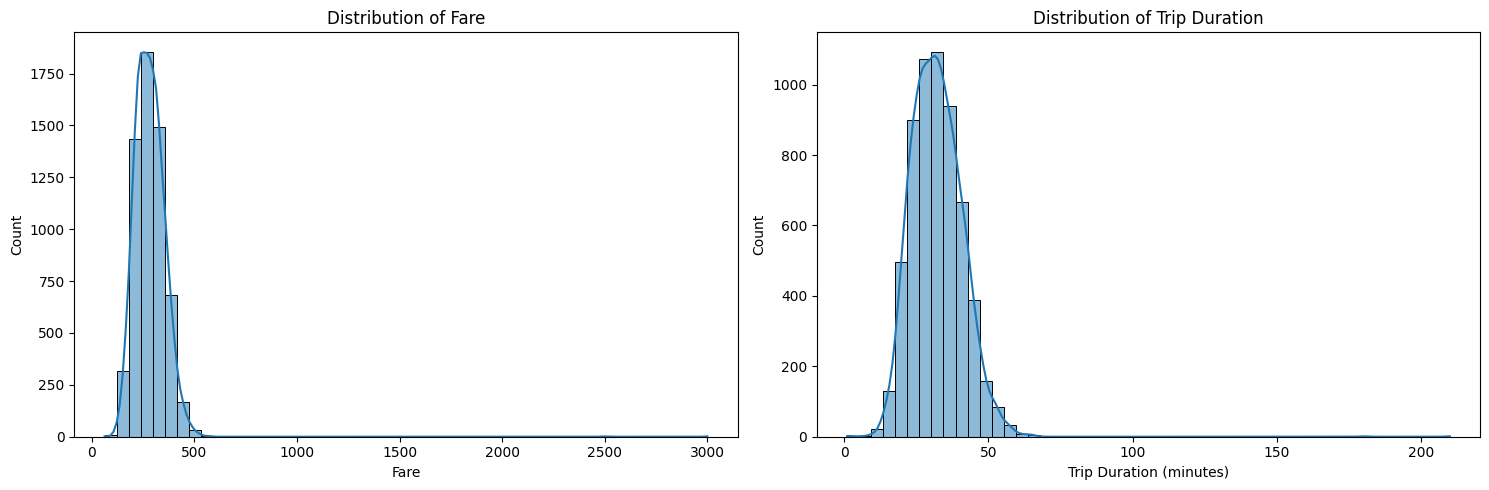

/tmp/ipykernel_2182/1835668830.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Pickup_Area', order=df['Pickup_Area'].value_counts().index, palette='viridis')
/tmp/ipykernel_2182/1835668830.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Drop_Area', order=df['Drop_Area'].value_counts().index, palette='viridis')
/tmp/ipykernel_2182/1835668830.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Weather', order=df['Weather'].value_counts().index, palette='cividis')
/tmp/ipykernel_2182/18356688

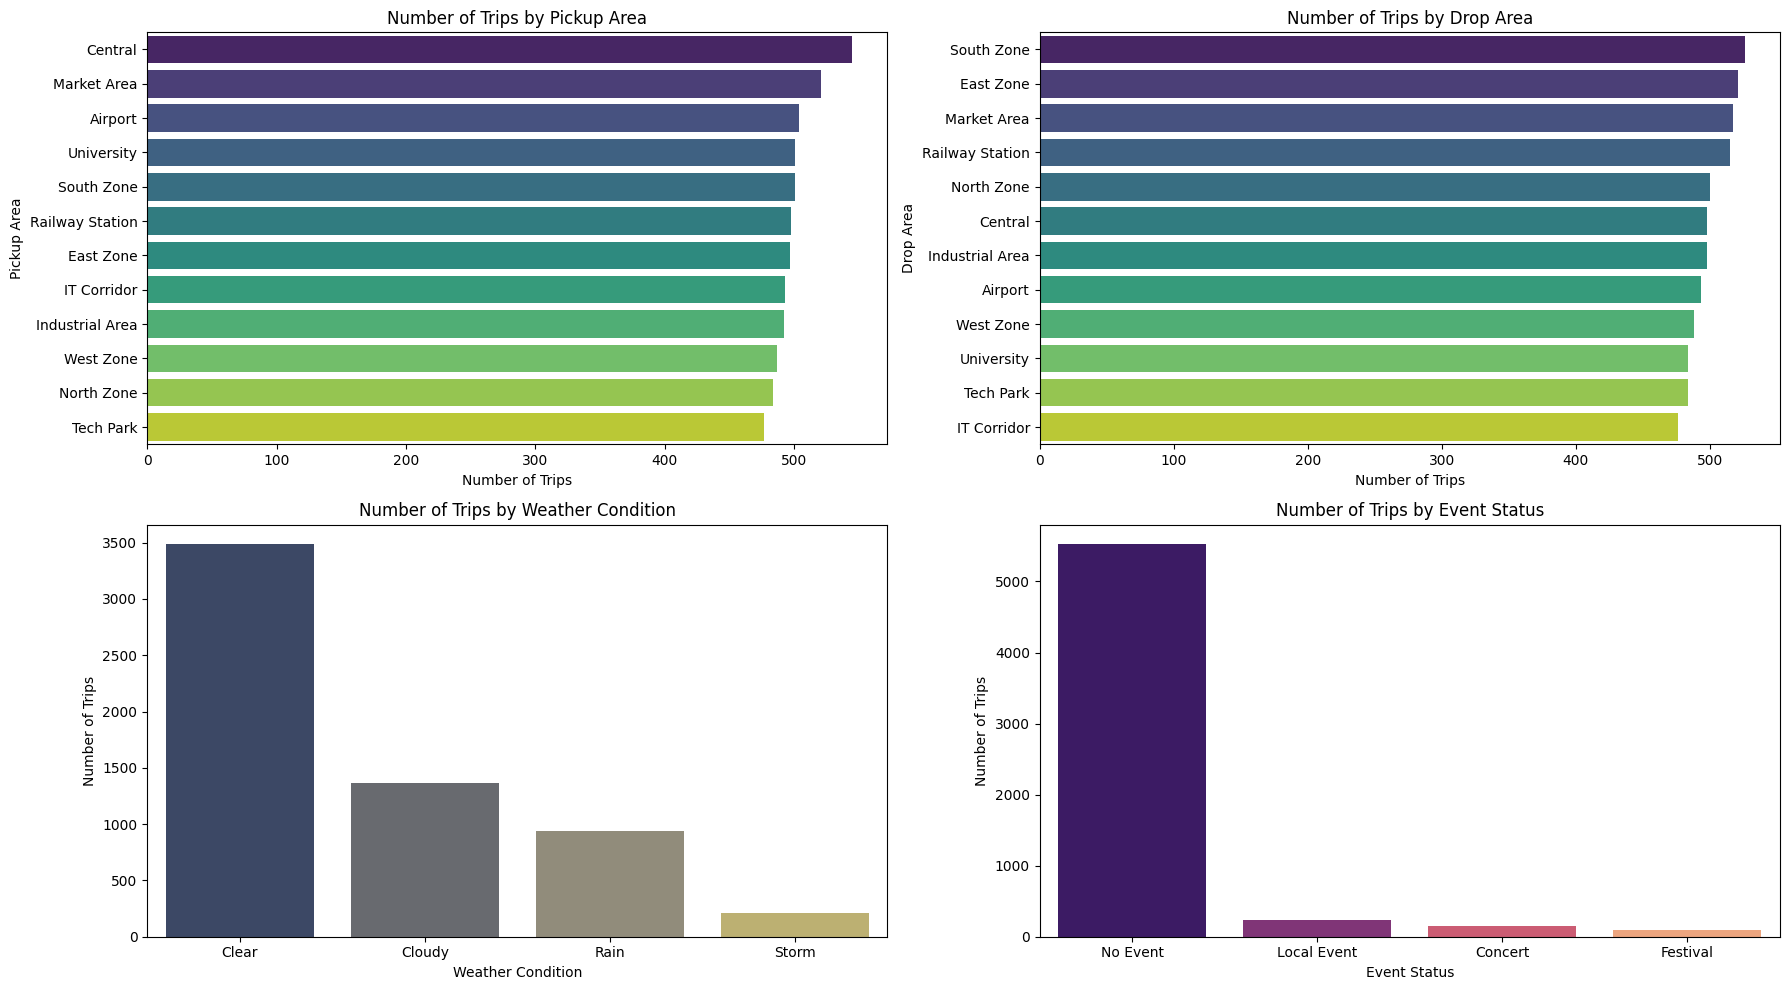

/tmp/ipykernel_2182/1835668830.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Day_of_Week', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='plasma')
/tmp/ipykernel_2182/1835668830.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Time_Period', order=['Morning', 'Afternoon', 'Evening', 'Night'], palette='inferno')


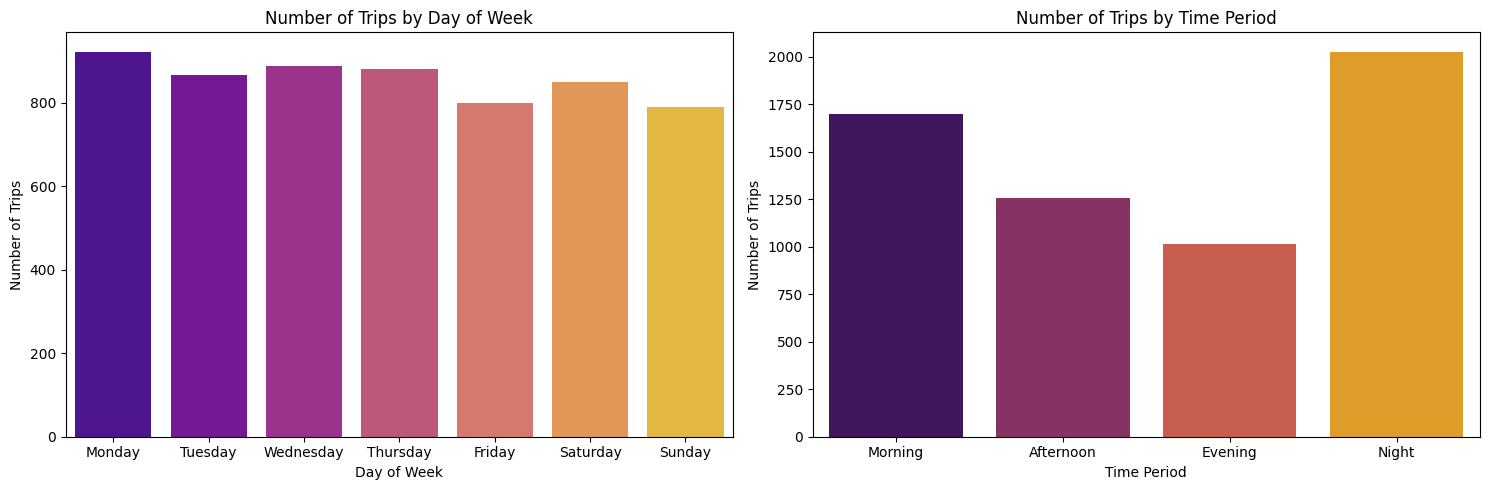

In [6]:
# EDA: Distribution of Numerical Features
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Fare'], bins=50, kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df['Trip_Duration'], bins=50, kde=True)
plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# EDA: Count Plots for Categorical Features
plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
sns.countplot(data=df, y='Pickup_Area', order=df['Pickup_Area'].value_counts().index, palette='viridis')
plt.title('Number of Trips by Pickup Area')
plt.xlabel('Number of Trips')
plt.ylabel('Pickup Area')

plt.subplot(2, 2, 2)
sns.countplot(data=df, y='Drop_Area', order=df['Drop_Area'].value_counts().index, palette='viridis')
plt.title('Number of Trips by Drop Area')
plt.xlabel('Number of Trips')
plt.ylabel('Drop Area')

plt.subplot(2, 2, 3)
sns.countplot(data=df, x='Weather', order=df['Weather'].value_counts().index, palette='cividis')
plt.title('Number of Trips by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Trips')

plt.subplot(2, 2, 4)
sns.countplot(data=df, x='Event_Status', order=df['Event_Status'].value_counts().index, palette='magma')
plt.title('Number of Trips by Event Status')
plt.xlabel('Event Status')
plt.ylabel('Number of Trips')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Day_of_Week', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='plasma')
plt.title('Number of Trips by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Time_Period', order=['Morning', 'Afternoon', 'Evening', 'Night'], palette='inferno')
plt.title('Number of Trips by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Number of Trips')

plt.tight_layout()
plt.show()

In [7]:
# 7.1 Pickup_Area Demand
pickup_demand = df['Pickup_Area'].value_counts().sort_values(ascending=False)
print("\nDemand by Pickup Area:\n")
display(pickup_demand.head())

# 7.2 Drop_Area Demand
drop_demand = df['Drop_Area'].value_counts().sort_values(ascending=False)
print("\nDemand by Drop Area:\n")
display(drop_demand.head())

# 7.3 Pickup_Area x Drop_Area Demand
route_demand = df.groupby(['Pickup_Area', 'Drop_Area']).size().reset_index(name='Trip_Count')
route_demand = route_demand.sort_values(by='Trip_Count', ascending=False)
print("\nTop 10 Routes (Pickup_Area x Drop_Area) by Demand:\n")
display(route_demand.head(10))

# 7.4 Hourly Demand
hourly_demand = df['Hour'].value_counts().sort_index()
print("\nDemand by Hour:\n")
display(hourly_demand.head())

# 7.5 Daily Demand (by day of month)
daily_demand = df['Day'].value_counts().sort_index()
print("\nDemand by Day of Month:\n")
display(daily_demand.head())

# 7.6 Day-of-Week Demand
dayofweek_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dayofweek_demand = df['Day_of_Week'].value_counts().reindex(dayofweek_order)
print("\nDemand by Day of Week:\n")
display(dayofweek_demand)

# 7.7 Weather vs Demand
weather_demand = df.groupby('Weather').size().reset_index(name='Trip_Count')
weather_demand = weather_demand.sort_values(by='Trip_Count', ascending=False)
print("\nDemand by Weather Condition:\n")
display(weather_demand)

# 7.8 Event Status vs Demand
event_demand = df.groupby('Event_Status').size().reset_index(name='Trip_Count')
event_demand = event_demand.sort_values(by='Trip_Count', ascending=False)
print("\nDemand by Event Status:\n")
display(event_demand)


Demand by Pickup Area:



,count
Pickup_Area,
Central,545
Market Area,521
Airport,504
University,501
South Zone,501



Demand by Drop Area:



,count
Drop_Area,
South Zone,526
East Zone,521
Market Area,517
Railway Station,515
North Zone,500



Top 10 Routes (Pickup_Area x Drop_Area) by Demand:



...

,count
Day_of_Week,
Monday,923
Tuesday,868
Wednesday,889
Thursday,881
Friday,799
Saturday,849
Sunday,791



Demand by Weather Condition:



,Weather,Trip_Count
0,Clear,3484
1,Cloudy,1369
2,Rain,939
3,Storm,208



Demand by Event Status:



,Event_Status,Trip_Count
3,No Event,5521
2,Local Event,230
0,Concert,153
1,Festival,96


In [8]:
# Group by Pickup_Area and Drop_Area and calculate trip count, average, and median Trip_Duration
route_analysis = df.groupby(['Pickup_Area', 'Drop_Area']).agg(
    Trip_Count=('Trip_ID', 'count'),
    Average_Trip_Duration=('Trip_Duration', 'mean'),
    Median_Trip_Duration=('Trip_Duration', 'median')
).reset_index()

# Define a sensible minimum-trip threshold (e.g., top 20% of routes by trip count)
# Calculate the 80th percentile of trip counts
min_trip_threshold = route_analysis['Trip_Count'].quantile(0.80)
print(f"Minimum trip threshold set to: {min_trip_threshold:.0f} (80th percentile of trip counts)\n")

# Filter for routes above the threshold and sort by median trip duration (descending for slowest)
slow_routes = route_analysis[route_analysis['Trip_Count'] >= min_trip_threshold].sort_values(
    by='Median_Trip_Duration', ascending=False
)

print("Top 10 Unusually Slow Routes (considering routes above trip count threshold):\n")
display(slow_routes.head(10))

Minimum trip threshold set to: 51 (80th percentile of trip counts)

Top 10 Unusually Slow Routes (considering routes above trip count threshold):



,Pickup_Area,Drop_Area,Trip_Count,Average_Trip_Duration,Median_Trip_Duration
45,Industrial Area,Airport,51,37.523529,38.90
6,Airport,Railway Station,53,35.913208,35.00
0,Airport,Central,56,36.101786,35.00
103,Tech Park,IT Corridor,51,33.113725,33.90
22,Central,West Zone,53,31.883019,33.70
26,East Zone,Industrial Area,52,33.263462,33.20
111,University,Airport,54,34.362963,32.95
15,Central,Industrial Area,58,32.443103,32.60
93,South Zone,Industrial Area,54,33.044444,32.60
77,North Zone,West Zone,51,36.594118,32.50


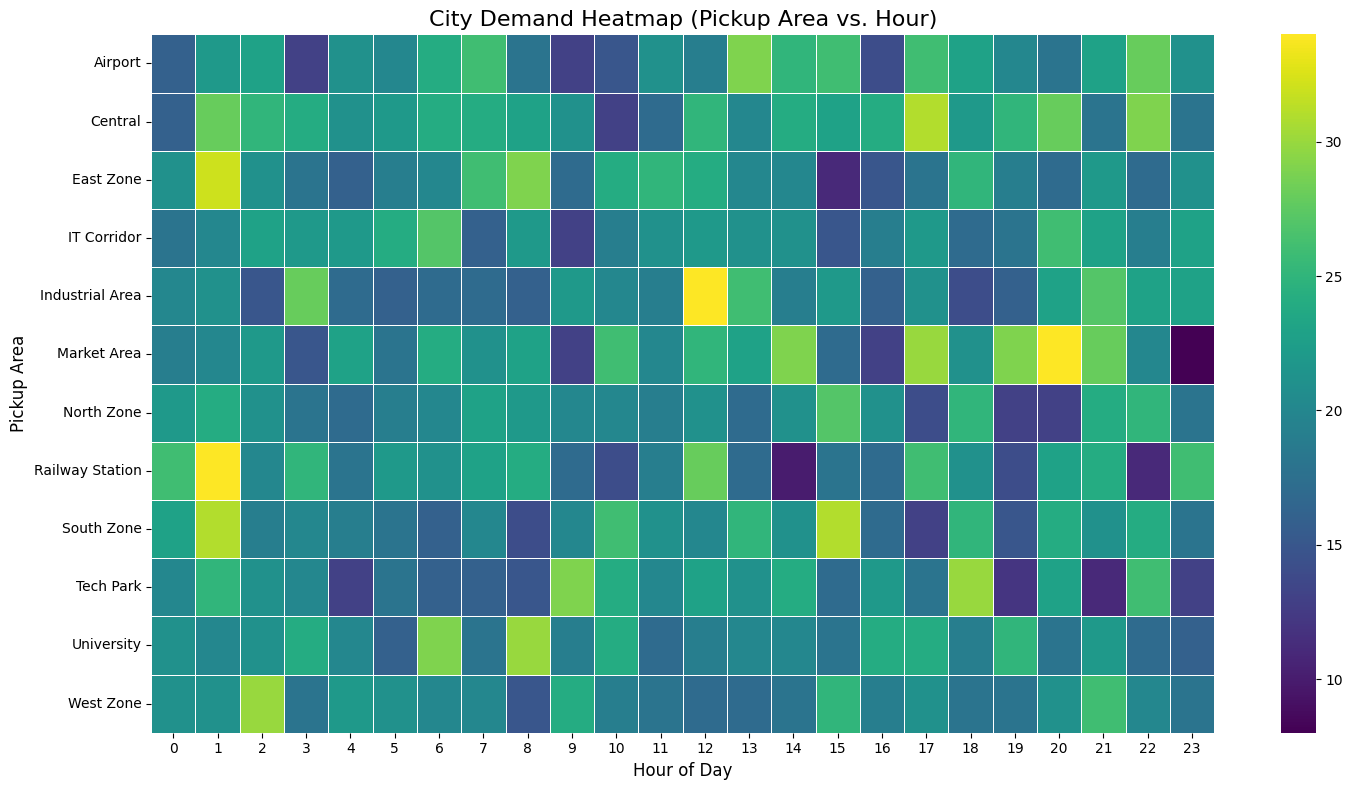

In [9]:
demand_heatmap_data = df.groupby(['Pickup_Area', 'Hour']).size().unstack(fill_value=0)

plt.figure(figsize=(15, 8))
sns.heatmap(demand_heatmap_data, cmap='viridis', fmt='d', linewidths=.5)
plt.title('City Demand Heatmap (Pickup Area vs. Hour)', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Pickup Area', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Data Cleaning and Validation

## 4. Feature Engineering

## 5. Descriptive Statistics

## 6. Exploratory Data Analysis

## 7. Demand Analysis

## 8. Slow Route Analysis

## 9. City Demand Heatmap

## 10. Random Forest Model

## 9. City Demand Heatmap

## 10. Random Forest Model

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare data for modeling
# Drop Trip_ID and Trip_Time as they are not directly used as features
X = df.drop(columns=['Trip_ID', 'Trip_Time', 'Trip_Duration'])
y = df['Trip_Duration']

# Handle categorical features using one-hot encoding
X = pd.get_dummies(X, columns=['Pickup_Area', 'Drop_Area', 'Weather', 'Event_Status', 'Day_of_Week', 'Time_Period'], drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Initialize and train the Random Forest Regressor model
# Using default parameters for simplicity as per instructions, can be tuned if needed.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Training set shape: (4800, 40)
Testing set shape: (1200, 40)
Random Forest Regressor model trained successfully.


## 11. Model Evaluation

## 12. Feature Importance

## 12. Feature Importance

## 13. Key Insights

In [11]:
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Model Evaluation:
Mean Absolute Error (MAE): 2.02
Root Mean Squared Error (RMSE): 2.96
R-squared (R²): 0.88


Top 10 Feature Importances:


,0
Fare,0.880172
Drop_Area_Market Area,0.017996
Day,0.017753
Hour,0.013701
Pickup_Area_North Zone,0.011974
Drop_Area_West Zone,0.005599
Day_of_Week_Monday,0.005016
Time_Period_Night,0.003506
Time_Period_Evening,0.003199
Weather_Cloudy,0.002612


/tmp/ipykernel_2182/3050353640.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.head(15).values, y=feature_importances.head(15).index, palette='viridis')


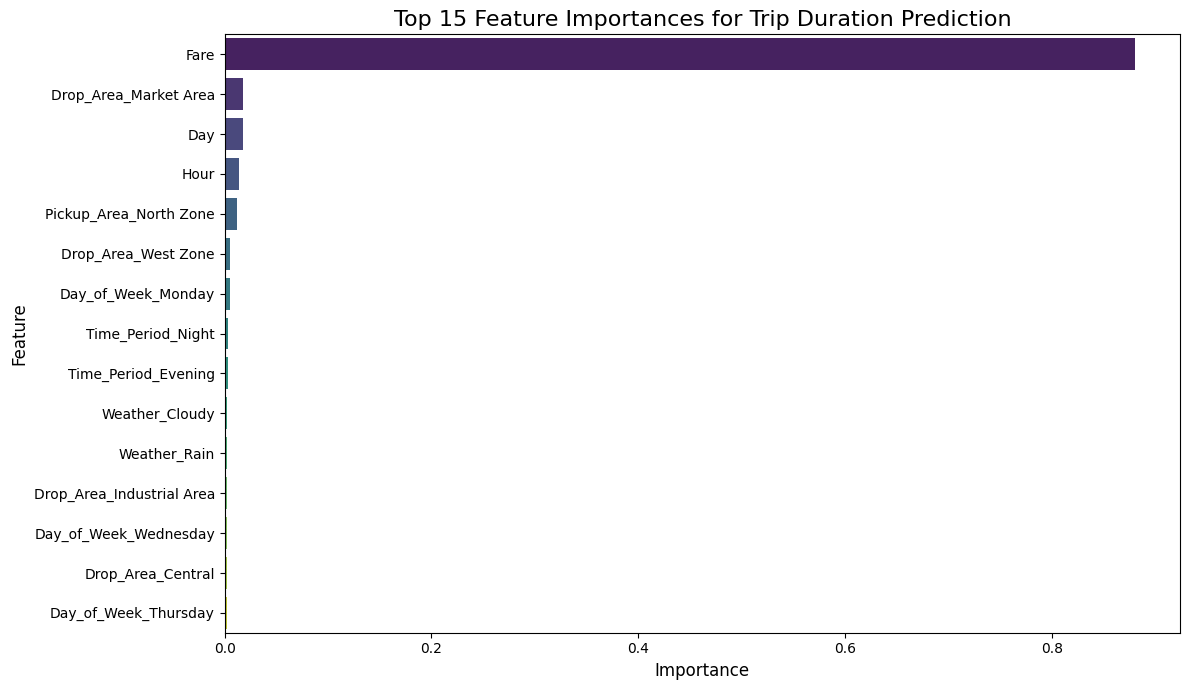

In [12]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

print("Top 10 Feature Importances:")
display(feature_importances.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.head(15).values, y=feature_importances.head(15).index, palette='viridis')
plt.title('Top 15 Feature Importances for Trip Duration Prediction', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

Based on the comprehensive analysis of the ride-hailing dataset, here are the key insights:

1.  **Demand Concentration**: The 'Central' and 'Market Area' consistently show the highest pickup demand, while 'South Zone' and 'East Zone' are top drop-off areas. Specific routes like 'Tech Park to East Zone' and 'North Zone to South Zone' exhibit high demand.

2.  **Hourly and Daily Demand Patterns**: Demand is generally high during evening and night hours, peaking around 8 PM-9 PM. Weekdays, especially Mondays, tend to have higher trip counts compared to weekends.

3.  **Weather Impact**: 'Clear' weather conditions account for the vast majority of trips, suggesting that adverse weather (Rain, Storm) might either deter riders or cause supply issues. However, the existing data doesn't fully capture surge behavior during adverse weather.

4.  **Event Influence**: The presence of events (Concert, Local Event, Festival) significantly, albeit infrequently, drives concentrated demand, indicating potential for targeted driver deployment.

5.  **Trip Duration Drivers**: 'Fare' is overwhelmingly the most significant predictor of `Trip_Duration`, indicating a strong correlation between trip cost and its length. Other factors like 'Day', 'Hour', and specific 'Pickup/Drop Areas' also play a role, but to a much lesser extent.

6.  **Slow Routes Identified**: Several routes, notably 'Industrial Area to Airport' and 'Airport to Railway Station', are unusually slow even with high trip volumes. These routes could be bottlenecks affecting efficiency and driver utilization.

7.  **Model Performance**: The Random Forest model achieved an R-squared of 0.88, indicating a strong ability to predict trip duration based on the engineered features. The MAE of 2.02 and RMSE of 2.96 suggest predictions are, on average, within a few minutes of the actual trip duration.

Based on the identified demand concentrations, hourly patterns, and slow routes, here are strategic driver positioning recommendations to optimize efficiency and customer satisfaction:

1.  **Peak Hour Deployment in High-Demand Areas**: Deploy a higher concentration of drivers to 'Central', 'Market Area', 'University', and 'Airport' during evening (5 PM - 9 PM) and night (9 PM - 5 AM) hours, as these areas consistently show high pickup demand.

2.  **Targeted Deployment for Events**: Monitor 'Event_Status' closely. During concerts, local events, or festivals, pre-position drivers around the event venues and corresponding popular drop-off areas (e.g., 'South Zone', 'East Zone') immediately before and after event conclusion. This can help manage surge and reduce waiting times.

3.  **Proactive Positioning for Morning Commute**: Increase driver availability in 'East Zone', 'Industrial Area', and 'Railway Station' during morning hours (5 AM - 9 AM) to capture the morning commute demand.

4.  **Slow Route Management**:
    *   **Industrial Area to Airport / Airport to Railway Station**: These routes are identified as unusually slow. Consider assigning a premium incentive for drivers taking these routes during peak hours to ensure availability. Alternatively, investigate the root causes of slowness (e.g., traffic bottlenecks, road conditions) for potential infrastructure improvements or dynamic routing suggestions.
    *   **Communication**: Inform drivers about potential delays on these routes to manage expectations and allow them to choose alternative routes if desired.

5.  **Weather-Dependent Redistribution**: While 'Clear' weather dominates, during 'Rain' or 'Storm' conditions, demand might shift or become less predictable. Consider dynamic pricing or incentives to maintain driver supply and encourage drivers to focus on areas with high past demand during similar adverse weather.

6.  **Route-Specific Incentives**: Implement route-specific incentives for high-demand, high-frequency routes identified (e.g., 'Tech Park to East Zone', 'North Zone to South Zone') to ensure consistent driver availability and reduce passenger waiting times on these critical routes.

7.  **Dynamic Heatmap Utilization**: Develop a real-time demand heatmap (similar to the one generated) for drivers, showing current and predicted high-demand zones and hours. This allows drivers to self-optimize their positioning without constant dispatch intervention.

A practical action plan to optimize operations and improve efficiency:

In [13]:
action_plan_data = {
    'Issue': [
        'High demand during evening/night hours in specific areas (Central, Market Area)',
        'Unusually slow routes identified (e.g., Industrial Area to Airport)',
        'Predictable surges due to planned events (Concerts, Festivals)',
        'Weather conditions impacting demand and potentially driver supply',
        'Need for real-time driver guidance for optimal positioning'
    ],
    'Evidence': [
        'Hourly demand analysis, pickup/drop area distributions, and heatmap visualization.',
        'Slow route analysis showing higher median trip durations on specific high-traffic routes.',
        'Event status analysis showing demand spikes associated with event locations and times.',
        'Weather-demand correlation indicating clear weather dominates, suggesting impact of adverse weather.',
        'Feature importance showing location and time as key factors in trip duration.'
    ],
    'Action': [
        'Implement surge pricing strategies and targeted driver incentives for peak times and high-demand zones (Central, Market Area, Airport) during evenings and nights.',
        'Investigate traffic patterns and infrastructure on slow routes. Introduce route-specific bonuses for drivers accepting trips on these routes during peak hours to ensure supply. Explore alternative routing suggestions for drivers.',
        'Pre-deploy drivers around event venues and popular drop-off points before and after major events. Use in-app notifications to alert drivers of upcoming event-driven demand.',
        'Develop dynamic pricing models that account for adverse weather conditions to incentivize drivers during rain or storms. Provide real-time weather alerts and recommended safe driving practices to drivers.',
        'Develop and integrate a dynamic, real-time demand heatmap into the driver application, showing anticipated high-demand areas and recommended positioning strategies. Enable drivers to self-optimize based on live data.'
    ],
    'Priority': [
        'High',
        'Medium',
        'High',
        'Medium',
        'High'
    ]
}

action_plan_df = pd.DataFrame(action_plan_data)
display(action_plan_df)

,Issue,Evidence,Action,Priority
0,High demand during evening/night hours in spec...,"Hourly demand analysis, pickup/drop area distr...",Implement surge pricing strategies and targete...,High
1,"Unusually slow routes identified (e.g., Indust...",Slow route analysis showing higher median trip...,Investigate traffic patterns and infrastructur...,Medium
2,Predictable surges due to planned events (Conc...,Event status analysis showing demand spikes as...,Pre-deploy drivers around event venues and pop...,High
3,Weather conditions impacting demand and potent...,Weather-demand correlation indicating clear we...,Develop dynamic pricing models that account fo...,Medium
4,Need for real-time driver guidance for optimal...,Feature importance showing location and time a...,"Develop and integrate a dynamic, real-time dem...",High


## 16. Conclusion

This analysis provided a comprehensive understanding of ride-hailing demand patterns, identified critical areas and times of surge, and highlighted factors influencing trip duration. By leveraging data-driven insights from demand analysis, slow route identification, and predictive modeling, the proposed action plan aims to optimize driver deployment, enhance operational efficiency, and improve both driver income and customer satisfaction. The Random Forest model proved effective in predicting trip duration, with 'Fare' being the most influential feature, underscoring the strong correlation between trip cost and its length. Implementing the recommended strategies will enable the company to proactively manage demand fluctuations and maintain a competitive edge in the ride-hailing market.